In [ ]:
#Activity log
#Bolortulga Seded
#18/02/2026
#Week 2 - Task 3: Find and Replace Missing Values — train.csv 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print(df.isnull().sum())
print((df.isnull().sum() / len(df)) * 100)
missing_cols = df.columns[df.isnull().any()]
print(missing_cols.tolist())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64
['Age', 'Cabin', 'Embarked']


In [6]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


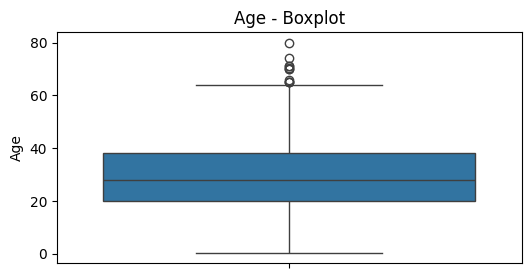

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if df[col].isnull().sum() >0:
        plt.figure(figsize=(6,3))
        sns.boxplot(df[col])
        plt.title(f"{col} - Boxplot")
        plt.show()

In [6]:
df_mean = df.copy()
for col in df_mean.select_dtypes(include=np.number).columns:
    if df_mean[col].isnull().sum() > 0:
        mean_val = df_mean[col].mean()
        df_mean[col] = df_mean[col].fillna(mean_val)
        print(f"[MEAN] '{col}' filled with: {mean_val:.2f}")
print("\nRemaining nulls:")
print(df_mean.isnull().sum())

[MEAN] 'Age' filled with: 29.70

Remaining nulls:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
df_median = df.copy()

for col in df_median.select_dtypes(include=np.number).columns:
    if df_median[col].isnull().sum() > 0:
        median_val = df_median[col].median()
        df_median[col] = df_median[col].fillna(median_val)
        print(f"[MEDIAN] '{col}' filled with: {median_val:.2f}")
print("\nRemaining nulls:")
print(df_median.isnull().sum())

[MEDIAN] 'Age' filled with: 28.00

Remaining nulls:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [12]:
df_mode = df.copy()

for col in df_mode.select_dtypes(include=['object', 'str']).columns:
    if df_mode[col].isnull().sum() > 0:
        mode_val = df_mode[col].mode()[0]
        df_mode[col] = df_mode[col].fillna(mode_val)
        print(f"[MODE] '{col}' filled with: '{mode_val}'")

print("\nRemaining nulls:")
print(df_mode.isnull().sum())

[MODE] 'Cabin' filled with: 'B96 B98'
[MODE] 'Embarked' filled with: 'S'

Remaining nulls:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
dtype: int64
